<h1 style='color:pink;'><center>Optimisation Hospitalière</center></h1>



<h3 style='color:blue;'> Installation & Configuration </h3>

In [1]:

print(" TEST IMPORTS PYGRAMETL 2.9 ✓")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
import pygrametl
from pygrametl import ConnectionWrapper   

print("✅ PANDAS:", pd.__version__)
print("✅ NUMPY:", np.__version__)
print("✅ MATPLOTLIB:", plt.matplotlib.__version__)
print("✅ SEABORN:", sns.__version__)
print("✅ PYGRAMETL:", pygrametl.__version__)
print("✅ PSYCOPG2:", psycopg2.__version__)

pd.set_option('display.max_columns', None)
plt.style.use('default')
print("\n🎉 ENVIRONNEMENT PARFAIT !")


 TEST IMPORTS PYGRAMETL 2.9 ✓
✅ PANDAS: 3.0.1
✅ NUMPY: 2.4.2
✅ MATPLOTLIB: 3.10.8
✅ SEABORN: 0.13.2
✅ PYGRAMETL: 2.9
✅ PSYCOPG2: 2.9.11 (dt dec pq3 ext lo64)

🎉 ENVIRONNEMENT PARFAIT !


<h3 style='color:blue;'> Connexion PostgreSQL </h3>

In [2]:
#  POSTGRESQL
DB_CONFIG = {
    'host': 'localhost',
    'database': 'healthcare_dwh',
    'user': 'postgres', 
    'password': 'BD2025',
    'port': 5432
}
# Documentation officielle pygramETL : https://pygrametl.org/doc/quickstart/beginner.html
try:
    conn = ConnectionWrapper(psycopg2.connect(**DB_CONFIG))
    print("✅ POSTGRESQL OK !")
except Exception as e:
    print(f"❌ {e}\n Crée DB hospital_dwh dans pgAdmin")

✅ POSTGRESQL OK !


<h3 style='color:blue;'> Etape 1: Extraction des sources de données </h3>

In [3]:
print("🔄 ÉTAPE 1 : EXTRACTION MULTI-SOURCES")

# CHEMINS ABSOLUS 
BASE_PATH = r"C:\Users\khadd\Desktop\DWH\healthcare-dwh\data"

# SOURCE 1 : CSV Kaggle
df_health = pd.read_csv(f"{BASE_PATH}/healthcare.csv")
print(f"📊 Source 1 - Healthcare: {df_health.shape}")

# SOURCE 2 : TXT Hospital Types (ignorer le header)
with open(f"{BASE_PATH}/hospital_type.txt", "r") as f:
    all_lines = f.readlines()
    hospital_types = [line.strip() for line in all_lines[1:] if line.strip() and line.strip() != "Hospital"]

print(f"📄 Source 2 - Types: {len(hospital_types)} (header ignoré)")
print("Types:", hospital_types[:5], "...")

# SOURCE 3 : CSV Disease Categories  
df_disease_cat = pd.read_csv(f"{BASE_PATH}/disease_category.csv")
print(f"📊 Source 3 - Maladies: {df_disease_cat.shape}")
print(df_disease_cat.head())

# Qualité
print(f"\n📈 Healthcare Info:")
print(df_health.info())
print(f"Dupliqués: {df_health.duplicated().sum()}")
print(f"Manquants: {df_health.isnull().sum().sum()}")

# SOURCE 4 : Données géographiques (fictives pour enrichissement)
unique_hospitals = df_health['Hospital'].unique()
n_hospitals = len(unique_hospitals)

# Créer des listes de la bonne longueur
cities = ['Paris', 'Lyon', 'Marseille', 'Bordeaux', 'Lille'] * (n_hospitals // 5 + 1)
regions = ['Île-de-France', 'Auvergne-Rhône-Alpes', 'Provence-Alpes-Côte d\'Azur', 'Nouvelle-Aquitaine', 'Hauts-de-France'] * (n_hospitals // 5 + 1)

df_geo = pd.DataFrame({
    'Hospital': unique_hospitals,
    'city': cities[:n_hospitals],
    'region': regions[:n_hospitals]
})
print(f"📊 Source 4 - Géographique: {df_geo.shape}")

🔄 ÉTAPE 1 : EXTRACTION MULTI-SOURCES
📊 Source 1 - Healthcare: (55500, 15)
📄 Source 2 - Types: 9 (header ignoré)
Types: ['public', 'private', 'university', 'military', 'Specialised Cardio'] ...
📊 Source 3 - Maladies: (7, 2)
  Medical Condition    Category
0          Diabetes     Chronic
1            Cancer     Chronic
2      Hypertension     Chronic
3            Asthma     Chronic
4               Flu  Infectious

📈 Healthcare Info:
<class 'pandas.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  str    
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  str    
 3   Blood Type          55500 non-null  str    
 4   Medical Condition   55500 non-null  str    
 5   Date of Admission   55500 non-null  str    
 6   Doctor              55500 non-null  str    
 7   Hospital            5

<h3 style='color:blue;'> Etape 2: Transformation (Pandas) </h3>

In [4]:
print("🔄 ÉTAPE 2 : TRANSFORMATION AVEC PANDAS (0 NaN)")

# Nettoyage
df_health_clean = df_health.drop_duplicates().dropna()
print(f"Après nettoyage: {df_health_clean.shape}")

# Feature Engineering 
def transform_health_data(df, hospital_types, df_disease_cat):
    df = df.copy()
    
    # 1. Age groups
    def age_group(age):
        if pd.isna(age): return "Unknown"
        if age < 18: return "0-17"
        elif age < 35: return "18-34"
        elif age < 60: return "35-59"
        else: return "60+"
    df['age_group'] = df['Age'].apply(age_group)
    
    # 2. Dates & Durée séjour (#KPI 1)
    df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
    df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])
    df['length_of_stay_days'] = (df['Discharge Date'] - df['Date of Admission']).dt.days
    
    # 3. Hospital types
    hospitals = df['Hospital'].unique()
    hospital_type_map = {hospitals[i]: hospital_types[i % len(hospital_types)] 
                        for i in range(len(hospitals))}
    df['hospital_type'] = df['Hospital'].map(hospital_type_map)
    
    # 4. Disease categories 
    df = df.merge(df_disease_cat, on='Medical Condition', how='left')
    df['Category'] = df['Category'].fillna('Non-Classée')  
    
    return df

# EXECUTION
df_transformed = transform_health_data(df_health_clean, hospital_types, df_disease_cat)
print("✅ Dataset transformé:", df_transformed.shape)

# VÉRIFICATION 0 NaN
print(f"✅ NaN Category: {df_transformed['Category'].isna().sum()}")
print("Répartition catégories:")
print(df_transformed['Category'].value_counts())

print("\n📊 APERÇU:")
print(df_transformed[['Hospital', 'hospital_type', 'Medical Condition', 
                      'Category', 'length_of_stay_days', 'age_group']].head())

🔄 ÉTAPE 2 : TRANSFORMATION AVEC PANDAS (0 NaN)
Après nettoyage: (54966, 15)
✅ Dataset transformé: (54966, 19)
✅ NaN Category: 0
Répartition catégories:
Category
Chronic        36602
Non-Classée    18364
Name: count, dtype: int64

📊 APERÇU:
                     Hospital       hospital_type Medical Condition  \
0             Sons and Miller              public            Cancer   
1                     Kim Inc             private           Obesity   
2                    Cook PLC          university           Obesity   
3  Hernandez Rogers and Vang,            military          Diabetes   
4                 White-White  Specialised Cardio            Cancer   

      Category  length_of_stay_days age_group  
0      Chronic                    2     18-34  
1  Non-Classée                    6       60+  
2  Non-Classée                   15       60+  
3      Chronic                   30     18-34  
4      Chronic                   20     35-59  


<h3 style='color:blue;'> Etape 3: Modélisation Multidimentionnelle </h3>
<h3 style='color:yellow;'> Schéma Etoile </h3>

In [5]:
print(" ÉTAPE 3 : MODÉLISATION SCHÉMA ÉTOILE")

# MODÈLE CONCEPTUEL MULTIDIMENSIONNEL (SCHÉMA ÉTOILE)

"""
TABLE DE FAITS : fact_patient_admission
| patient_id | hospital_id | doctor_id | disease_id | insurance_id | date_id | billing_amount | length_of_stay_days | patient_count |

DIMENSIONS :
dim_patient    : patient_id, name, age, gender, blood_type, age_group
dim_hospital   : hospital_id, hospital_name, hospital_type, city, region
dim_doctor     : doctor_id, doctor_name
dim_disease    : disease_id, medical_condition, category
dim_insurance  : insurance_id, provider_name
dim_date       : date_id, full_date, day, month, year, quarter, month_name
"""

# Création des clés surrogées
def create_surrogate_keys(df):
    df = df.copy()

    # Patient ID
    df['patient_id'] = range(1, len(df) + 1)
    
    # Hospital ID
    hospital_map = {h: i+1 for i, h in enumerate(df['Hospital'].unique())}
    df['hospital_id'] = df['Hospital'].map(hospital_map)
    
    # Doctor ID
    doctor_map = {d: i+1 for i, d in enumerate(df['Doctor'].unique())}
    df['doctor_id'] = df['Doctor'].map(doctor_map)
    
    # Disease ID
    disease_map = {d: i+1 for i, d in enumerate(df['Medical Condition'].unique())}
    df['disease_id'] = df['Medical Condition'].map(disease_map)
    
    # Insurance ID
    insurance_map = {i: j+1 for j, i in enumerate(df['Insurance Provider'].unique())}
    df['insurance_id'] = df['Insurance Provider'].map(insurance_map)
    
    return df

df_with_keys = create_surrogate_keys(df_transformed)
print("✅ Clés surrogées créées")

# VÉRIFICATION 
print(f"📊 Dataset: {df_with_keys.shape}")
print("IDs uniques:", df_with_keys[['hospital_id','doctor_id','disease_id','insurance_id']].nunique())

 ÉTAPE 3 : MODÉLISATION SCHÉMA ÉTOILE
✅ Clés surrogées créées
📊 Dataset: (54966, 24)
IDs uniques: hospital_id     39876
doctor_id       40341
disease_id          6
insurance_id        5
dtype: int64


<h3 style='color: blue'> Etape 4: Création Dim_Date </h3>

In [6]:
print(" 📅 Etape 4:  DIMENSION DATE ")

# Création date_id
unique_dates = df_with_keys['Date of Admission'].drop_duplicates().sort_values()

dim_date = pd.DataFrame({
    'date_id': range(1, len(unique_dates) + 1),
    'full_date': unique_dates,
    'day': unique_dates.dt.day,
    'month': unique_dates.dt.month,
    'year': unique_dates.dt.year,
    'quarter': unique_dates.dt.quarter,
    'month_name': unique_dates.dt.strftime('%B'),
    'day_name': unique_dates.dt.day_name(),
    'is_weekend': (unique_dates.dt.weekday >= 5).astype(int)
})

# Mapping
date_map = dict(zip(unique_dates, dim_date['date_id']))
df_with_keys['date_id'] = df_with_keys['Date of Admission'].map(date_map)

print("✅ Dim Date:", dim_date.shape)
print(dim_date.head())
print("\nDataset avec date_id:", df_with_keys['date_id'].nunique(), "valeurs uniques")

 📅 Etape 4:  DIMENSION DATE 
✅ Dim Date: (1827, 9)
      date_id  full_date  day  month  year  quarter month_name   day_name  \
1683        1 2019-05-08    8      5  2019        2        May  Wednesday   
1257        2 2019-05-09    9      5  2019        2        May   Thursday   
623         3 2019-05-10   10      5  2019        2        May     Friday   
1845        4 2019-05-11   11      5  2019        2        May   Saturday   
470         5 2019-05-12   12      5  2019        2        May     Sunday   

      is_weekend  
1683           0  
1257           0  
623            0  
1845           1  
470            1  

Dataset avec date_id: 1827 valeurs uniques


<h3 style='color:blue;'> Etape 5: Connexion & Création des Tables PygramETL </h3>

In [7]:
print("🏗️ SCHÉMA ÉTOILE ")

from pygrametl import ConnectionWrapper
import psycopg2

# RECONNEXION (car la précédente a été fermée)
pgconn = psycopg2.connect(**DB_CONFIG)
conn = ConnectionWrapper(pgconn)

# Schema brut 
conn.execute("DROP SCHEMA IF EXISTS healthcare_dwh CASCADE;")
conn.execute("""
    CREATE SCHEMA healthcare_dwh;
    
    -- 1. D'abord les tables DIMENSIONS (pas de dépendances)
    CREATE TABLE healthcare_dwh.dim_patient (
        patient_id SERIAL PRIMARY KEY, 
        name VARCHAR, age INT,
        gender VARCHAR, blood_type VARCHAR, age_group VARCHAR
    );
    
    CREATE TABLE healthcare_dwh.dim_hospital (
        hospital_id SERIAL PRIMARY KEY, 
        hospital_name VARCHAR, 
        hospital_type VARCHAR,
        city VARCHAR,
        region VARCHAR
    );
    
    CREATE TABLE healthcare_dwh.dim_doctor (
        doctor_id SERIAL PRIMARY KEY, 
        doctor_name VARCHAR
    );
    
    CREATE TABLE healthcare_dwh.dim_disease (
        disease_id SERIAL PRIMARY KEY, 
        medical_condition VARCHAR, category VARCHAR
    );
    
    CREATE TABLE healthcare_dwh.dim_insurance (
        insurance_id SERIAL PRIMARY KEY, 
        provider_name VARCHAR
    );
    
    CREATE TABLE healthcare_dwh.dim_date (
        date_id SERIAL PRIMARY KEY,
        full_date DATE, day INT, month INT, year INT, quarter INT,
        day_name VARCHAR, month_name VARCHAR, is_weekend INT
    );
    
    -- 2. Ensuite la table de FAITS (qui dépend des dimensions)
    CREATE TABLE healthcare_dwh.fact_patient_admission (
        admission_id SERIAL PRIMARY KEY,  --surrogate key
        patient_id INT NOT NULL,
        hospital_id INT NOT NULL,
        doctor_id INT NOT NULL,
        disease_id INT NOT NULL,
        insurance_id INT NOT NULL,
        date_id INT NOT NULL,
        billing_amount DECIMAL, 
        length_of_stay_days INT, 
        patient_count INT DEFAULT 1,
        FOREIGN KEY (patient_id) REFERENCES healthcare_dwh.dim_patient(patient_id),
        FOREIGN KEY (hospital_id) REFERENCES healthcare_dwh.dim_hospital(hospital_id),
        FOREIGN KEY (doctor_id) REFERENCES healthcare_dwh.dim_doctor(doctor_id),
        FOREIGN KEY (disease_id) REFERENCES healthcare_dwh.dim_disease(disease_id),
        FOREIGN KEY (insurance_id) REFERENCES healthcare_dwh.dim_insurance(insurance_id),
        FOREIGN KEY (date_id) REFERENCES healthcare_dwh.dim_date(date_id)
    );
    -- 3. Table de métadonnées pour le chargement incrémental
    CREATE TABLE healthcare_dwh.metadata_etl (
        id INT PRIMARY KEY DEFAULT 1,
        last_load_date TIMESTAMP,
        table_name VARCHAR,
        rows_loaded INT,
        CONSTRAINT single_row CHECK (id = 1)
    );
""")
conn.commit()

print("✅ 7 TABLES healthcare_dwh CRÉÉES DANS LE BON ORDRE")
print("   - Dimensions créées d'abord")
print("   - Table de faits créée ensuite avec ses clés étrangères")

🏗️ SCHÉMA ÉTOILE 
✅ 7 TABLES healthcare_dwh CRÉÉES DANS LE BON ORDRE
   - Dimensions créées d'abord
   - Table de faits créée ensuite avec ses clés étrangères


<h3 style='color:blue;'> Etape 6: Chargement ETL (PygramETL) </h3>

<h4 style='color:yellow;'> Chargement Dim_Date </h4>

In [8]:
print("📅 LOAD DIMENSION DATE")

# Données dim_date
date_data = [
    (row.full_date, int(row.day), int(row.month), int(row.year), 
     int(row.quarter), row.day_name, row.month_name, int(row.is_weekend))
    for _, row in dim_date.iterrows()
]

# INSERT avec pygramETL
conn.executemany("""
    INSERT INTO healthcare_dwh.dim_date 
    (full_date, day, month, year, quarter, day_name, month_name, is_weekend)
    VALUES (%s, %s, %s, %s, %s, %s, %s, %s)
""", date_data)
conn.commit()

print(f"✅ {len(date_data)} dates chargées")

📅 LOAD DIMENSION DATE
✅ 1827 dates chargées


<h4 style='color:yellow;'> Chargement  </h4>

<h4 style='color:yellow;'> Création des DataFrames pour Les Dimensions </h4>

In [9]:
print("🏥 CRÉATION DATAFRAMES DIMENSIONS")

# IMPORTANT: Utiliser df_transformed, PAS df_with_keys
# df_transformed contient les noms réels, df_with_keys contient des IDs pandas

dim_patient = df_transformed[['Name', 'Age', 'Gender', 'Blood Type', 'age_group']].drop_duplicates()
dim_patient.columns = ['name', 'age', 'gender', 'blood_type', 'age_group']

# dim_hospital avec données géographiques
dim_hospital = df_transformed[['Hospital', 'hospital_type']].drop_duplicates()
dim_hospital = dim_hospital.merge(df_geo[['Hospital', 'city', 'region']], on='Hospital', how='left')
dim_hospital = dim_hospital.rename(columns={'Hospital': 'hospital_name'})
# Les colonnes sont maintenant: hospital_name, hospital_type, city, region

dim_doctor = df_transformed[['Doctor']].drop_duplicates()
dim_doctor.columns = ['doctor_name']

dim_disease = df_transformed[['Medical Condition', 'Category']].drop_duplicates()
dim_disease.columns = ['medical_condition', 'category']

dim_insurance = df_transformed[['Insurance Provider']].drop_duplicates()
dim_insurance.columns = ['provider_name']

print("✅ 5 DataFrames créés (sans IDs, uniquement les valeurs uniques):")
print(f"Patient: {dim_patient.shape}")
print(f"Hospital: {dim_hospital.shape}")
print(f"Doctor: {dim_doctor.shape}")
print(f"Disease: {dim_disease.shape}")
print(f"Insurance: {dim_insurance.shape}")
print(f"Colonnes Hospital: {dim_hospital.columns.tolist()}")

🏥 CRÉATION DATAFRAMES DIMENSIONS
✅ 5 DataFrames créés (sans IDs, uniquement les valeurs uniques):
Patient: (54966, 5)
Hospital: (39876, 4)
Doctor: (40341, 1)
Disease: (6, 2)
Insurance: (5, 1)
Colonnes Hospital: ['hospital_name', 'hospital_type', 'city', 'region']


<h4 style='color:yellow;'> Chargement des Dimensions </h4>

In [10]:
print("🔄 CRÉATION ET CHARGEMENT DES DIMENSIONS")

# Nettoyer les tables existantes avec pygramETL
print("🗑️ Nettoyage des tables...")
conn.execute("TRUNCATE TABLE healthcare_dwh.dim_patient CASCADE")
conn.execute("TRUNCATE TABLE healthcare_dwh.dim_hospital CASCADE")
conn.execute("TRUNCATE TABLE healthcare_dwh.dim_doctor CASCADE")
conn.execute("TRUNCATE TABLE healthcare_dwh.dim_disease CASCADE")
conn.execute("TRUNCATE TABLE healthcare_dwh.dim_insurance CASCADE")
conn.execute("TRUNCATE TABLE healthcare_dwh.fact_patient_admission CASCADE")
conn.commit()

print("✅ Tables vidées")

# 1. DIM_PATIENT
print("\n📝 Chargement DIM_PATIENT...")
patient_data = [
    (row['name'], int(row['age']), row['gender'], row['blood_type'], row['age_group'])
    for _, row in dim_patient.iterrows()
]

conn.executemany("""
    INSERT INTO healthcare_dwh.dim_patient 
    (name, age, gender, blood_type, age_group)
    VALUES (%s, %s, %s, %s, %s)
""", patient_data)
conn.commit()
print(f"  ✅ {len(patient_data)} patients uniques chargés")

# 2. DIM_HOSPITAL
print("\n📝 Chargement DIM_HOSPITAL...")
hospital_data = [
    (row['hospital_name'], row['hospital_type'], row['city'], row['region'])
    for _, row in dim_hospital.iterrows()
]

conn.executemany("""
    INSERT INTO healthcare_dwh.dim_hospital 
    (hospital_name, hospital_type, city, region)
    VALUES (%s, %s, %s, %s)
""", hospital_data)
conn.commit()
print(f"  ✅ {len(hospital_data)} hôpitaux uniques chargés")

# 3. DIM_DOCTOR
print("\n📝 Chargement DIM_DOCTOR...")
doctor_data = [(row['doctor_name'],) for _, row in dim_doctor.iterrows()]

conn.executemany("""
    INSERT INTO healthcare_dwh.dim_doctor 
    (doctor_name)
    VALUES (%s)
""", doctor_data)
conn.commit()
print(f"  ✅ {len(doctor_data)} docteurs uniques chargés")

# 4. DIM_DISEASE
print("\n📝 Chargement DIM_DISEASE...")
disease_data = [
    (row['medical_condition'], row['category'])
    for _, row in dim_disease.iterrows()
]

conn.executemany("""
    INSERT INTO healthcare_dwh.dim_disease 
    (medical_condition, category)
    VALUES (%s, %s)
""", disease_data)
conn.commit()
print(f"  ✅ {len(disease_data)} maladies uniques chargées")

# 5. DIM_INSURANCE
print("\n📝 Chargement DIM_INSURANCE...")
insurance_data = [(row['provider_name'],) for _, row in dim_insurance.iterrows()]

conn.executemany("""
    INSERT INTO healthcare_dwh.dim_insurance 
    (provider_name)
    VALUES (%s)
""", insurance_data)
conn.commit()
print(f"  ✅ {len(insurance_data)} assurances uniques chargées")

print("\n✅ TOUTES LES DIMENSIONS RECRÉÉES CORRECTEMENT")

🔄 CRÉATION ET CHARGEMENT DES DIMENSIONS
🗑️ Nettoyage des tables...
✅ Tables vidées

📝 Chargement DIM_PATIENT...
  ✅ 54966 patients uniques chargés

📝 Chargement DIM_HOSPITAL...
  ✅ 39876 hôpitaux uniques chargés

📝 Chargement DIM_DOCTOR...
  ✅ 40341 docteurs uniques chargés

📝 Chargement DIM_DISEASE...
  ✅ 6 maladies uniques chargées

📝 Chargement DIM_INSURANCE...
  ✅ 5 assurances uniques chargées

✅ TOUTES LES DIMENSIONS RECRÉÉES CORRECTEMENT


In [11]:
print("🔄 ANNULATION DE LA TRANSACTION ET AJOUT DE LAST_UPDATE")

# Annuler la transaction en cours
conn.rollback()
print("  ✅ Transaction annulée")

# Ajouter la colonne
try:
    conn.execute("""
        ALTER TABLE healthcare_dwh.fact_patient_admission 
        ADD COLUMN IF NOT EXISTS last_update TIMESTAMP DEFAULT CURRENT_TIMESTAMP;
    """)
    conn.commit()
    print("✅ Colonne last_update ajoutée avec succès")
except Exception as e:
    print(f"❌ Erreur: {e}")

🔄 ANNULATION DE LA TRANSACTION ET AJOUT DE LAST_UPDATE
  ✅ Transaction annulée
✅ Colonne last_update ajoutée avec succès


<h4 style='color:yellow;'> Chargement de La Table des Faits </h4>

In [12]:
print("📊 CHARGEMENT DE LA TABLE DE FAITS")

# Créer un cursor via pygramETL
cursor = conn.cursor()

# Récupérer les mappings des dates
print("🔄 Récupération des mappings...")
cursor.execute("SELECT date_id, full_date FROM healthcare_dwh.dim_date")
date_map = {}
for date_id, full_date in cursor.fetchall():
    if hasattr(full_date, 'date'):
        date_map[full_date.date()] = date_id
    else:
        date_map[full_date] = date_id
print(f"  ✅ {len(date_map)} dates mappées")

# Récupérer les mappings des dimensions
cursor.execute("SELECT patient_id, name FROM healthcare_dwh.dim_patient")
patient_map = {name: pid for pid, name in cursor.fetchall()}
print(f"  ✅ {len(patient_map)} patients mappés")

cursor.execute("SELECT hospital_id, hospital_name FROM healthcare_dwh.dim_hospital")
hospital_map = {name: hid for hid, name in cursor.fetchall()}
print(f"  ✅ {len(hospital_map)} hôpitaux mappés")

cursor.execute("SELECT doctor_id, doctor_name FROM healthcare_dwh.dim_doctor")
doctor_map = {name: did for did, name in cursor.fetchall()}
print(f"  ✅ {len(doctor_map)} docteurs mappés")

cursor.execute("SELECT disease_id, medical_condition FROM healthcare_dwh.dim_disease")
disease_map = {condition: did for did, condition in cursor.fetchall()}
print(f"  ✅ {len(disease_map)} maladies mappées")

cursor.execute("SELECT insurance_id, provider_name FROM healthcare_dwh.dim_insurance")
insurance_map = {provider: iid for iid, provider in cursor.fetchall()}
print(f"  ✅ {len(insurance_map)} assurances mappées")

# Préparer les données de faits
print("\n🛠️ Préparation des données de faits...")
fact_data = []
missing_count = 0

for _, row in df_transformed.iterrows():
    patient_id = patient_map.get(row['Name'])
    hospital_id = hospital_map.get(row['Hospital'])
    doctor_id = doctor_map.get(row['Doctor'])
    disease_id = disease_map.get(row['Medical Condition'])
    insurance_id = insurance_map.get(row['Insurance Provider'])
    
    # Convertir la date
    date_value = row['Date of Admission']
    if hasattr(date_value, 'date'):
        date_simple = date_value.date()
    else:
        date_simple = date_value
    
    date_id = date_map.get(date_simple)
    
    if None in [patient_id, hospital_id, doctor_id, disease_id, insurance_id, date_id]:
        missing_count += 1
    else:
        # AJOUT DE last_update
        from datetime import datetime
        fact_data.append((
            patient_id, hospital_id, doctor_id, disease_id, 
            insurance_id, date_id,
            float(row['Billing Amount']), 
            int(row['length_of_stay_days']), 
            1,
            datetime.now()  # ← NOUVEAU : timestamp
        ))

print(f"\n📊 Résultat:")
print(f"  ✅ Lignes valides: {len(fact_data)} sur {len(df_transformed)}")
if missing_count > 0:
    print(f"  ⚠️ Lignes ignorées: {missing_count}")

# Insertion avec pygramETL
if len(fact_data) > 0:
    print("\n💾 Insertion dans fact_patient_admission...")
    batch_size = 10000
    for i in range(0, len(fact_data), batch_size):
        batch = fact_data[i:i+batch_size]
        cursor.executemany("""
            INSERT INTO healthcare_dwh.fact_patient_admission 
            (patient_id, hospital_id, doctor_id, disease_id, insurance_id, 
             date_id, billing_amount, length_of_stay_days, patient_count, last_update)
            VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
        """, batch)
        print(f"  ✅ Batch {i//batch_size + 1}: {len(batch)} lignes insérées")
    
    conn.commit()
    print(f"\n🎉 FACT TABLE CHARGÉE AVEC SUCCÈS: {len(fact_data)} admissions")
    
    # ===== NOUVEAU : Mettre à jour metadata_etl =====
    from datetime import datetime
    cursor.execute("""
        UPDATE healthcare_dwh.metadata_etl 
        SET last_load_date = %s, rows_loaded = rows_loaded + %s, table_name = 'initial'
        WHERE id = 1
    """, (datetime.now(), len(fact_data)))
    conn.commit()
    print("  ✅ Date de dernier chargement enregistrée dans metadata_etl")
    # ================================================
    
    # Petit aperçu
    print("\n📊 Aperçu des 5 premières admissions:")
    cursor.execute("""
        SELECT f.admission_id, p.name, d.medical_condition, 
               f.billing_amount, f.length_of_stay_days
        FROM healthcare_dwh.fact_patient_admission f
        JOIN healthcare_dwh.dim_patient p ON f.patient_id = p.patient_id
        JOIN healthcare_dwh.dim_disease d ON f.disease_id = d.disease_id
        LIMIT 5
    """)
    for row in cursor.fetchall():
        print(f"  Admission {row[0]}: {row[1][:20]}... | {row[2]} | ${row[3]:.2f} | {row[4]} jours")
    
    cursor.close()
else:
    print("\n❌ Aucune ligne à insérer. Vérifie les mappings.")
    cursor.close()

📊 CHARGEMENT DE LA TABLE DE FAITS
🔄 Récupération des mappings...
  ✅ 1827 dates mappées
  ✅ 49992 patients mappés
  ✅ 39876 hôpitaux mappés
  ✅ 40341 docteurs mappés
  ✅ 6 maladies mappées
  ✅ 5 assurances mappées

🛠️ Préparation des données de faits...

📊 Résultat:
  ✅ Lignes valides: 54966 sur 54966

💾 Insertion dans fact_patient_admission...
  ✅ Batch 1: 10000 lignes insérées
  ✅ Batch 2: 10000 lignes insérées
  ✅ Batch 3: 10000 lignes insérées
  ✅ Batch 4: 10000 lignes insérées
  ✅ Batch 5: 10000 lignes insérées
  ✅ Batch 6: 4966 lignes insérées

🎉 FACT TABLE CHARGÉE AVEC SUCCÈS: 54966 admissions
  ✅ Date de dernier chargement enregistrée dans metadata_etl

📊 Aperçu des 5 premières admissions:
  Admission 1: Bobby JacksOn... | Cancer | $18856.28 | 2 jours
  Admission 2: LesLie TErRy... | Obesity | $33643.33 | 6 jours
  Admission 3: DaNnY sMitH... | Obesity | $27955.10 | 15 jours
  Admission 4: andrEw waTtS... | Diabetes | $37909.78 | 30 jours
  Admission 5: adrIENNE bEll... | Cance

<h4 style='color:yellow;'> Chargement incrémental </h4>

In [13]:
print("📈 CRÉATION DE LA FONCTION DE CHARGEMENT INCRÉMENTAL")

from datetime import datetime

def load_incremental():
    """
    Charge uniquement les nouvelles admissions depuis le dernier chargement.
    """
    cursor = conn.cursor()
    
    # Récupérer la date du dernier chargement
    cursor.execute("SELECT last_load_date FROM healthcare_dwh.metadata_etl WHERE id = 1")
    result = cursor.fetchone()
    last_load = result[0] if result else datetime(1900, 1, 1)
    print(f"  Dernier chargement: {last_load}")
    
    # Vérifier si df_transformed a la colonne last_update
    if 'last_update' not in df_transformed.columns:
        print("  ❌ La colonne last_update n'existe pas dans df_transformed")
        cursor.close()
        return 0
    
    # Filtrer les nouvelles données
    new_data = df_transformed[df_transformed['last_update'] > last_load]
    
    if len(new_data) == 0:
        print("  Aucune nouvelle donnée à charger.")
        cursor.close()
        return 0
    
    print(f"  Nouvelles lignes détectées: {len(new_data)}")
    
    # Récupérer les mappings
    cursor.execute("SELECT patient_id, name FROM healthcare_dwh.dim_patient")
    patient_map = {name: pid for pid, name in cursor.fetchall()}
    
    cursor.execute("SELECT hospital_id, hospital_name FROM healthcare_dwh.dim_hospital")
    hospital_map = {name: hid for hid, name in cursor.fetchall()}
    
    cursor.execute("SELECT doctor_id, doctor_name FROM healthcare_dwh.dim_doctor")
    doctor_map = {name: did for did, name in cursor.fetchall()}
    
    cursor.execute("SELECT disease_id, medical_condition FROM healthcare_dwh.dim_disease")
    disease_map = {condition: did for did, condition in cursor.fetchall()}
    
    cursor.execute("SELECT insurance_id, provider_name FROM healthcare_dwh.dim_insurance")
    insurance_map = {provider: iid for iid, provider in cursor.fetchall()}
    
    cursor.execute("SELECT date_id, full_date FROM healthcare_dwh.dim_date")
    date_map = {}
    for date_id, full_date in cursor.fetchall():
        if hasattr(full_date, 'date'):
            date_map[full_date.date()] = date_id
        else:
            date_map[full_date] = date_id
    
    # Préparer les données
    fact_data = []
    for _, row in new_data.iterrows():
        patient_id = patient_map.get(row['Name'])
        hospital_id = hospital_map.get(row['Hospital'])
        doctor_id = doctor_map.get(row['Doctor'])
        disease_id = disease_map.get(row['Medical Condition'])
        insurance_id = insurance_map.get(row['Insurance Provider'])
        
        date_value = row['Date of Admission']
        if hasattr(date_value, 'date'):
            date_simple = date_value.date()
        else:
            date_simple = date_value
        date_id = date_map.get(date_simple)
        
        if None not in [patient_id, hospital_id, doctor_id, disease_id, insurance_id, date_id]:
            fact_data.append((
                patient_id, hospital_id, doctor_id, disease_id,
                insurance_id, date_id,
                float(row['Billing Amount']),
                int(row['length_of_stay_days']), 1,
                row['last_update']
            ))
    
    # Insertion
    if fact_data:
        cursor.executemany("""
            INSERT INTO healthcare_dwh.fact_patient_admission 
            (patient_id, hospital_id, doctor_id, disease_id, insurance_id, 
             date_id, billing_amount, length_of_stay_days, patient_count, last_update)
            VALUES (%s, %s, %s, %s, %s, %s, %s, %s, %s, %s)
        """, fact_data)
        
        # Mettre à jour la métadonnée
        new_last_load = new_data['last_update'].max()
        cursor.execute("""
            UPDATE healthcare_dwh.metadata_etl 
            SET last_load_date = %s, rows_loaded = rows_loaded + %s, table_name = 'incremental'
            WHERE id = 1
        """, (new_last_load, len(fact_data)))
        
        conn.commit()
        print(f"  ✅ {len(fact_data)} nouvelles lignes insérées")
        print(f"  Nouvelle date de dernier chargement: {new_last_load}")
    
    cursor.close()
    return len(fact_data)

print("✅ Fonction load_incremental() créée avec succès")

📈 CRÉATION DE LA FONCTION DE CHARGEMENT INCRÉMENTAL
✅ Fonction load_incremental() créée avec succès


<h3 style='color:blue;'> Etape 7: Validation Data WareHouse </h3>

In [14]:
print("🔍 ÉTAPE 5 : VALIDATION DE LA DATA WAREHOUSE")

# Utiliser la connexion pygramETL existante
cursor = conn.cursor()

# 2. Compter les lignes chargées
print("\n📊 COMPTE-RENDU CHARGEMENT:")
tables = ['dim_patient', 'dim_hospital', 'dim_doctor', 'dim_disease', 'dim_insurance', 'dim_date', 'fact_patient_admission']
for table in tables:
    cursor.execute(f"SELECT COUNT(*) FROM healthcare_dwh.{table}")
    count = cursor.fetchone()[0]
    print(f"  ✅ {table}: {count:,} lignes")

# 3. Vérifier l'intégrité référentielle (pas d'ordures)
print("\n🔗 INTÉGRITÉ RÉFÉRENTIELLE:")
cursor.execute("""
    SELECT 
        (SELECT COUNT(*) FROM healthcare_dwh.fact_patient_admission f 
         LEFT JOIN healthcare_dwh.dim_patient p ON f.patient_id = p.patient_id 
         WHERE p.patient_id IS NULL) as orphan_patients,
        (SELECT COUNT(*) FROM healthcare_dwh.fact_patient_admission f 
         LEFT JOIN healthcare_dwh.dim_hospital h ON f.hospital_id = h.hospital_id 
         WHERE h.hospital_id IS NULL) as orphan_hospitals,
        (SELECT COUNT(*) FROM healthcare_dwh.fact_patient_admission f 
         LEFT JOIN healthcare_dwh.dim_doctor d ON f.doctor_id = d.doctor_id 
         WHERE d.doctor_id IS NULL) as orphan_doctors,
        (SELECT COUNT(*) FROM healthcare_dwh.fact_patient_admission f 
         LEFT JOIN healthcare_dwh.dim_disease dis ON f.disease_id = dis.disease_id 
         WHERE dis.disease_id IS NULL) as orphan_diseases,
        (SELECT COUNT(*) FROM healthcare_dwh.fact_patient_admission f 
         LEFT JOIN healthcare_dwh.dim_insurance i ON f.insurance_id = i.insurance_id 
         WHERE i.insurance_id IS NULL) as orphan_insurance,
        (SELECT COUNT(*) FROM healthcare_dwh.fact_patient_admission f 
         LEFT JOIN healthcare_dwh.dim_date dt ON f.date_id = dt.date_id 
         WHERE dt.date_id IS NULL) as orphan_dates
""")
orphans = cursor.fetchone()
print(f"  Patients orphelins:   {orphans[0]}")
print(f"  Hôpitaux orphelins:   {orphans[1]}")
print(f"  Docteurs orphelins:   {orphans[2]}")
print(f"  Maladies orphelines:  {orphans[3]}")
print(f"  Assurances orphelines: {orphans[4]}")
print(f"  Dates orphelines:     {orphans[5]}")

# 4. Vérifier les doublons dans les dimensions 
print("\n🔍 DOUBLONS DIMENSIONS:")
cursor.execute("""
    SELECT 'dim_patient' as dim, COUNT(*) - COUNT(DISTINCT name || '|' || age || '|' || gender) as dup_count 
    FROM healthcare_dwh.dim_patient
    UNION ALL
    SELECT 'dim_hospital', COUNT(*) - COUNT(DISTINCT hospital_name) 
    FROM healthcare_dwh.dim_hospital
    UNION ALL  
    SELECT 'dim_doctor', COUNT(*) - COUNT(DISTINCT doctor_name) 
    FROM healthcare_dwh.dim_doctor
    UNION ALL
    SELECT 'dim_disease', COUNT(*) - COUNT(DISTINCT medical_condition) 
    FROM healthcare_dwh.dim_disease
    UNION ALL
    SELECT 'dim_insurance', COUNT(*) - COUNT(DISTINCT provider_name) 
    FROM healthcare_dwh.dim_insurance
""")
duplicates = cursor.fetchall()
for dim, dup in duplicates:
    if dup == 0:
        print(f"  ✅ {dim}: {dup} doublons")
    else:
        print(f"  ⚠️ {dim}: {dup} doublons")

# 5. Statistiques de base sur la table de faits
print("\n📈 STATISTIQUES FAITS:")
cursor.execute("""
    SELECT 
        MIN(billing_amount) as min_bill,
        MAX(billing_amount) as max_bill,
        ROUND(AVG(billing_amount), 2) as avg_bill,
        MIN(length_of_stay_days) as min_stay,
        MAX(length_of_stay_days) as max_stay,
        ROUND(AVG(length_of_stay_days), 1) as avg_stay,
        COUNT(DISTINCT patient_id) as unique_patients,
        COUNT(DISTINCT hospital_id) as unique_hospitals,
        COUNT(DISTINCT doctor_id) as unique_doctors,
        COUNT(DISTINCT disease_id) as unique_diseases,
        COUNT(DISTINCT insurance_id) as unique_insurance
    FROM healthcare_dwh.fact_patient_admission
""")
stats = cursor.fetchone()
print(f"  Facturation: Min=${stats[0]:,.0f} | Max=${stats[1]:,.0f} | Moy=${stats[2]:,.0f}")
print(f"  Durée séjour: Min={stats[3]}j | Max={stats[4]}j | Moy={stats[5]:.1f}j")
print(f"  Patients uniques: {stats[6]:,} | Hôpitaux uniques: {stats[7]}")
print(f"  Docteurs uniques: {stats[8]:,} | Maladies uniques: {stats[9]}")
print(f"  Assurances uniques: {stats[10]}")

# 6. Vérification des clés étrangères 
print("\n🔐 VÉRIFICATION DES CONTRAINTES:")
cursor.execute("""
    SELECT conname, contype 
    FROM pg_constraint 
    WHERE conrelid = 'healthcare_dwh.fact_patient_admission'::regclass
""")
constraints = cursor.fetchall()
for conname, contype in constraints:
    if contype == 'p':
        print(f"  ✅ Clé primaire: {conname}")
    elif contype == 'f':
        print(f"  ✅ Clé étrangère: {conname}")

cursor.close()
print("\n✅ VALIDATION TERMINÉE")


🔍 ÉTAPE 5 : VALIDATION DE LA DATA WAREHOUSE

📊 COMPTE-RENDU CHARGEMENT:
  ✅ dim_patient: 54,966 lignes
  ✅ dim_hospital: 39,876 lignes
  ✅ dim_doctor: 40,341 lignes
  ✅ dim_disease: 6 lignes
  ✅ dim_insurance: 5 lignes
  ✅ dim_date: 1,827 lignes
  ✅ fact_patient_admission: 54,966 lignes

🔗 INTÉGRITÉ RÉFÉRENTIELLE:
  Patients orphelins:   0
  Hôpitaux orphelins:   0
  Docteurs orphelins:   0
  Maladies orphelines:  0
  Assurances orphelines: 0
  Dates orphelines:     0

🔍 DOUBLONS DIMENSIONS:
  ✅ dim_disease: 0 doublons
  ✅ dim_insurance: 0 doublons
  ✅ dim_hospital: 0 doublons
  ✅ dim_doctor: 0 doublons
  ✅ dim_patient: 0 doublons

📈 STATISTIQUES FAITS:
  Facturation: Min=$-2,008 | Max=$52,764 | Moy=$25,544
  Durée séjour: Min=1j | Max=30j | Moy=15.5j
  Patients uniques: 49,992 | Hôpitaux uniques: 39876
  Docteurs uniques: 40,341 | Maladies uniques: 6
  Assurances uniques: 5

🔐 VÉRIFICATION DES CONTRAINTES:
  ✅ Clé primaire: fact_patient_admission_pkey
  ✅ Clé étrangère: fact_patient_a

<h3 style='color:blue;'> Tableaux de Bord BI (Matplotlib) </h3>

<h4 style='color:pink;'> Imports & Connexion </h4>

In [15]:
print("📊 INITIALISATION DES KPIs")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Style
plt.style.use('default')
sns.set_style("whitegrid")

# Requête de base (commune à tous les KPIs)
query_base = """
SELECT 
    d.medical_condition,
    d.category,
    dp.age_group,
    dh.hospital_name,
    dh.hospital_type,
    dd.month_name,
    dd.month,
    dd.year,
    dd.quarter,
    AVG(f.length_of_stay_days) as avg_stay,
    AVG(f.billing_amount) as avg_cost,
    COUNT(*) as admission_count,
    SUM(f.patient_count) as total_patients
FROM healthcare_dwh.fact_patient_admission f
JOIN healthcare_dwh.dim_disease d ON f.disease_id = d.disease_id
JOIN healthcare_dwh.dim_patient dp ON f.patient_id = dp.patient_id
JOIN healthcare_dwh.dim_hospital dh ON f.hospital_id = dh.hospital_id
JOIN healthcare_dwh.dim_date dd ON f.date_id = dd.date_id
GROUP BY d.medical_condition, d.category, dp.age_group, 
         dh.hospital_name, dh.hospital_type, 
         dd.month_name, dd.month, dd.year, dd.quarter
"""

# Utiliser pgconn (la connexion psycopg2 sous-jacente) pour pandas
df_bi = pd.read_sql(query_base, pgconn)
print(f"✅ Dataset chargé: {df_bi.shape} lignes")

📊 INITIALISATION DES KPIs


C:\Users\khadd\AppData\Local\Temp\ipykernel_20960\2265263202.py:38: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_bi = pd.read_sql(query_base, pgconn)


✅ Dataset chargé: (49966, 13) lignes


<h4 style='color:pink;'><center> KPI 1: Top Maladies par Volume </center></h4>

C:\Users\khadd\AppData\Local\Temp\ipykernel_14548\3955814705.py:10: UserWarning: Glyph 127973 (\N{HOSPITAL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\khadd\AppData\Local\Temp\ipykernel_14548\3955814705.py:11: UserWarning: Glyph 127973 (\N{HOSPITAL}) missing from font(s) Arial.
  plt.savefig('kpi1_top_maladies.png', dpi=300, bbox_inches='tight')
C:\Users\khadd\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127973 (\N{HOSPITAL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


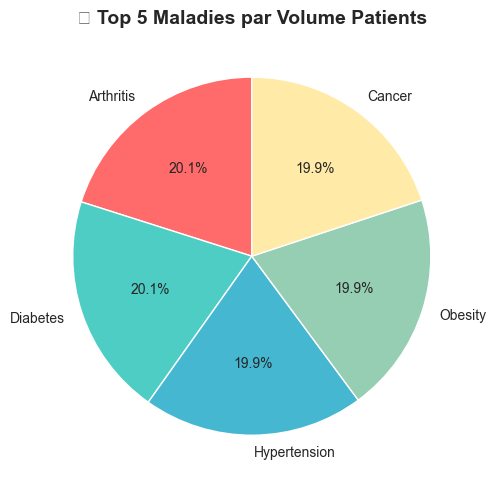

In [61]:

fig, ax = plt.subplots(figsize=(6, 5))

top_diseases = df_bi.groupby('medical_condition')['total_patients'].sum().nlargest(5)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']

wedges, texts, autotexts = ax.pie(top_diseases.values, labels=top_diseases.index, 
                                     autopct='%1.1f%%', colors=colors, startangle=90)
ax.set_title('🏥 Top 5 Maladies par Volume Patients', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig('kpi1_top_maladies.png', dpi=300, bbox_inches='tight')
plt.show()

<h4 style='color:pink;'><center> KPI 2: Evolution Charge Temporelle </center></h4>

C:\Users\khadd\AppData\Local\Temp\ipykernel_14548\2452513425.py:21: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\khadd\AppData\Local\Temp\ipykernel_14548\2452513425.py:22: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  plt.savefig('kpi2_evolution_temporelle.png', dpi=300, bbox_inches='tight')
C:\Users\khadd\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


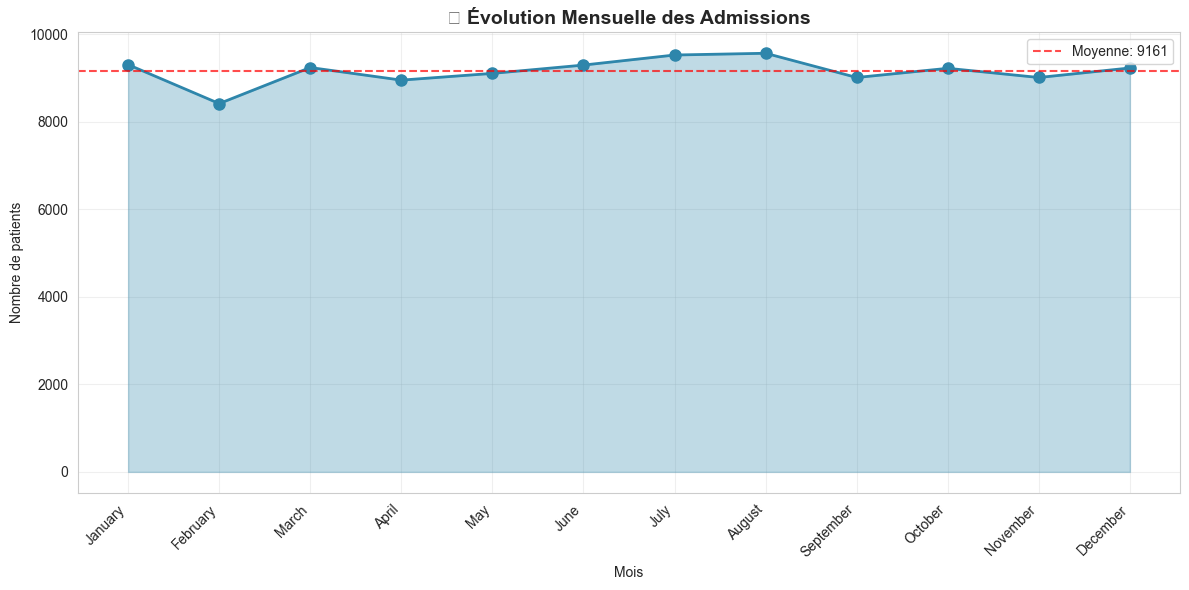

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_trend = df_bi.groupby('month_name')['total_patients'].sum().reindex(month_order)

ax.plot(monthly_trend.values, marker='o', linewidth=2, markersize=8, color='#2E86AB')
ax.fill_between(range(len(monthly_trend)), monthly_trend.values, alpha=0.3, color='#2E86AB')
ax.set_title('📅 Évolution Mensuelle des Admissions', fontweight='bold', fontsize=14)
ax.set_xlabel('Mois')
ax.set_ylabel('Nombre de patients')
ax.set_xticks(range(len(monthly_trend)))
ax.set_xticklabels(month_order, rotation=45, ha='right')
ax.grid(True, alpha=0.3)

# Ajouter la valeur moyenne
avg_line = monthly_trend.mean()
ax.axhline(y=avg_line, color='red', linestyle='--', alpha=0.7, label=f'Moyenne: {avg_line:.0f}')
ax.legend()

plt.tight_layout()
plt.savefig('kpi2_evolution_temporelle.png', dpi=300, bbox_inches='tight')
plt.show()

<h4 style='color:pink;'><center> KPI 3: Durée de Séjour par Age </center></h4>

C:\Users\khadd\AppData\Local\Temp\ipykernel_14548\1628070491.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_bi, x='age_group', y='avg_stay', palette='Blues', ax=ax)
C:\Users\khadd\AppData\Local\Temp\ipykernel_14548\1628070491.py:12: UserWarning: Glyph 128101 (\N{BUSTS IN SILHOUETTE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\khadd\AppData\Local\Temp\ipykernel_14548\1628070491.py:13: UserWarning: Glyph 128101 (\N{BUSTS IN SILHOUETTE}) missing from font(s) Arial.
  plt.savefig('kpi3_duree_sejour_age.png', dpi=300, bbox_inches='tight')
C:\Users\khadd\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128101 (\N{BUSTS IN SILHOUETTE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


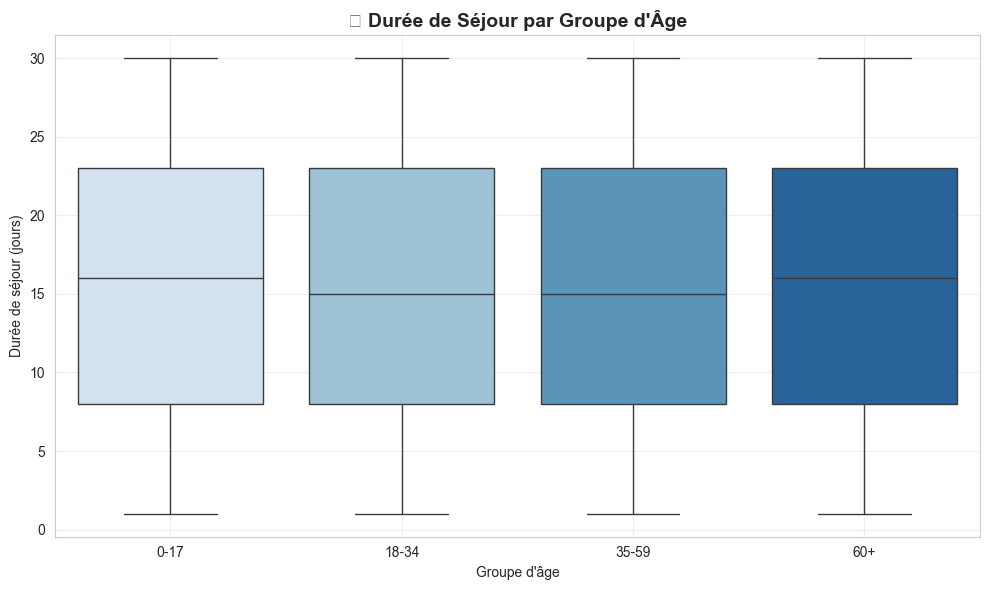

In [62]:
fig, ax = plt.subplots(figsize=(10, 6))

age_order = ['0-17', '18-34', '35-59', '60+']
df_bi['age_group'] = pd.Categorical(df_bi['age_group'], categories=age_order, ordered=True)

sns.boxplot(data=df_bi, x='age_group', y='avg_stay', palette='Blues', ax=ax)
ax.set_title('👥 Durée de Séjour par Groupe d\'Âge', fontweight='bold', fontsize=14)
ax.set_xlabel('Groupe d\'âge')
ax.set_ylabel('Durée de séjour (jours)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kpi3_duree_sejour_age.png', dpi=300, bbox_inches='tight')
plt.show()

<h4 style='color:pink;'><center> KPI 4: Coût Moyen par Catégorie Maladie </center></h4>

C:\Users\khadd\AppData\Local\Temp\ipykernel_14548\3150614935.py:13: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\khadd\AppData\Local\Temp\ipykernel_14548\3150614935.py:14: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) Arial.
  plt.savefig('kpi4_cout_par_categorie.png', dpi=300, bbox_inches='tight')


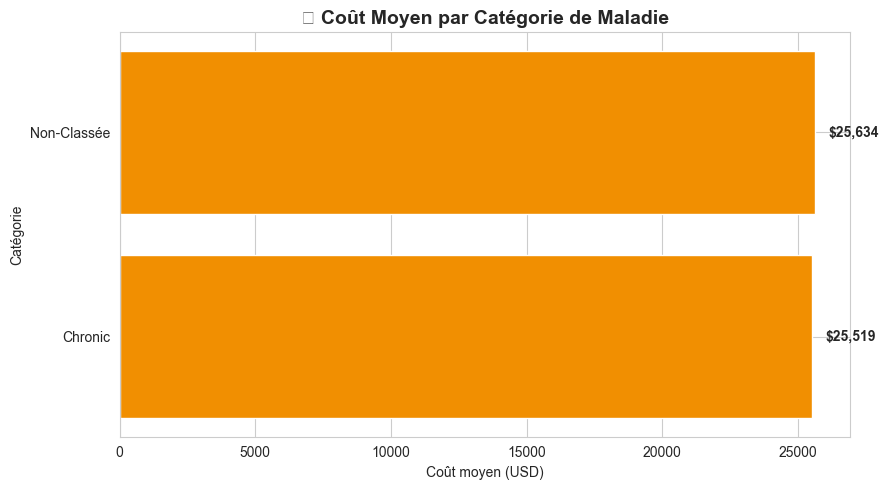

In [64]:
fig, ax = plt.subplots(figsize=(9, 5))

cost_by_cat = df_bi.groupby('category')['avg_cost'].mean().sort_values()
bars = ax.barh(cost_by_cat.index, cost_by_cat.values, color='#F18F01')
ax.set_title('💰 Coût Moyen par Catégorie de Maladie', fontweight='bold', fontsize=14)
ax.set_xlabel('Coût moyen (USD)')
ax.set_ylabel('Catégorie')

# Ajouter les valeurs sur les barres
for i, (cat, val) in enumerate(cost_by_cat.items()):
    ax.text(val + 500, i, f'${val:,.0f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('kpi4_cout_par_categorie.png', dpi=300, bbox_inches='tight')
plt.show()

<h4 style='color:pink;'><center> KPI 5: Charge par Type Hôpital </center></h4>

C:\Users\khadd\AppData\Local\Temp\ipykernel_14548\1146675463.py:15: UserWarning: Glyph 127976 (\N{HOTEL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\khadd\AppData\Local\Temp\ipykernel_14548\1146675463.py:16: UserWarning: Glyph 127976 (\N{HOTEL}) missing from font(s) Arial.
  plt.savefig('kpi5_charge_par_type_hopital.png', dpi=300, bbox_inches='tight')
C:\Users\khadd\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127976 (\N{HOTEL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


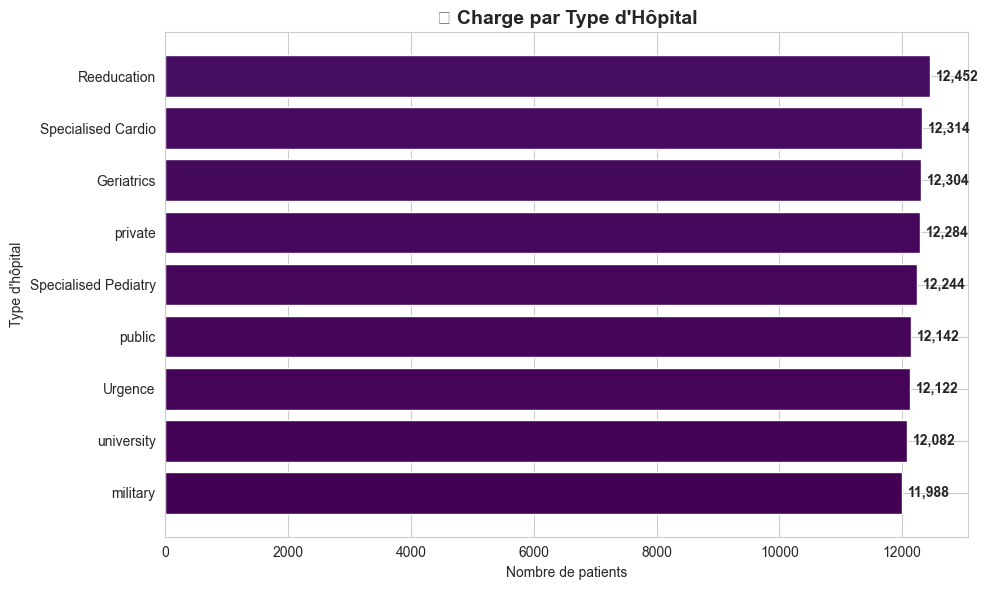

In [65]:
fig, ax = plt.subplots(figsize=(10, 6))

hospital_type_load = df_bi.groupby('hospital_type')['total_patients'].sum().sort_values(ascending=True)
colors_type = plt.cm.viridis(range(len(hospital_type_load)))

bars = ax.barh(hospital_type_load.index, hospital_type_load.values, color=colors_type)
ax.set_title('🏨 Charge par Type d\'Hôpital', fontweight='bold', fontsize=14)
ax.set_xlabel('Nombre de patients')
ax.set_ylabel('Type d\'hôpital')

# Ajouter les valeurs sur les barres
for i, (type_name, val) in enumerate(hospital_type_load.items()):
    ax.text(val + 100, i, f'{val:,.0f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('kpi5_charge_par_type_hopital.png', dpi=300, bbox_inches='tight')
plt.show()

<h4 style='color:pink;'><center> KPI 6: Patients par Groupe Age </center></h4>

C:\Users\khadd\AppData\Local\Temp\ipykernel_14548\4097787212.py:17: UserWarning: Glyph 128116 (\N{OLDER MAN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\khadd\AppData\Local\Temp\ipykernel_14548\4097787212.py:18: UserWarning: Glyph 128116 (\N{OLDER MAN}) missing from font(s) Arial.
  plt.savefig('kpi6_patients_par_age.png', dpi=300, bbox_inches='tight')
C:\Users\khadd\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128116 (\N{OLDER MAN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


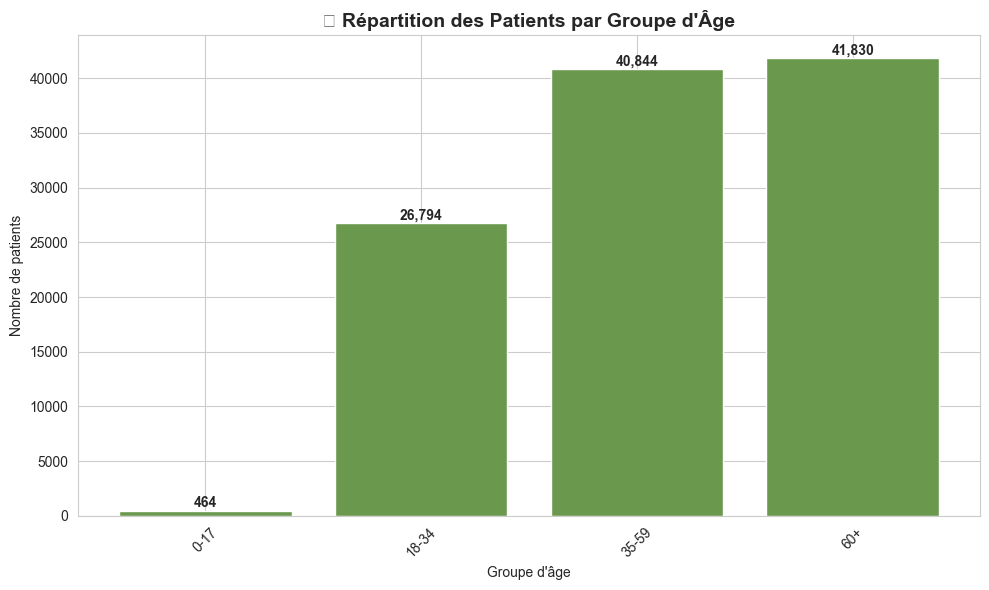

In [66]:
fig, ax = plt.subplots(figsize=(10, 6))

age_order = ['0-17', '18-34', '35-59', '60+']
age_patients = df_bi.groupby('age_group')['total_patients'].sum().reindex(age_order)

bars = ax.bar(age_patients.index, age_patients.values, color='#6A994E')
ax.set_title('👴 Répartition des Patients par Groupe d\'Âge', fontweight='bold', fontsize=14)
ax.set_xlabel('Groupe d\'âge')
ax.set_ylabel('Nombre de patients')
ax.tick_params(axis='x', rotation=45)

# Ajouter les valeurs sur les barres
for bar, val in zip(bars, age_patients.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
            f'{val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('kpi6_patients_par_age.png', dpi=300, bbox_inches='tight')
plt.show()

<h4 style='color:pink;'><center> KPI 7: Taux d'Occupation Temporelle </center></h4>

C:\Users\khadd\AppData\Local\Temp\ipykernel_14548\3684257382.py:30: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\khadd\AppData\Local\Temp\ipykernel_14548\3684257382.py:31: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  plt.savefig('kpi7_taux_occupation.png', dpi=300, bbox_inches='tight')
C:\Users\khadd\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


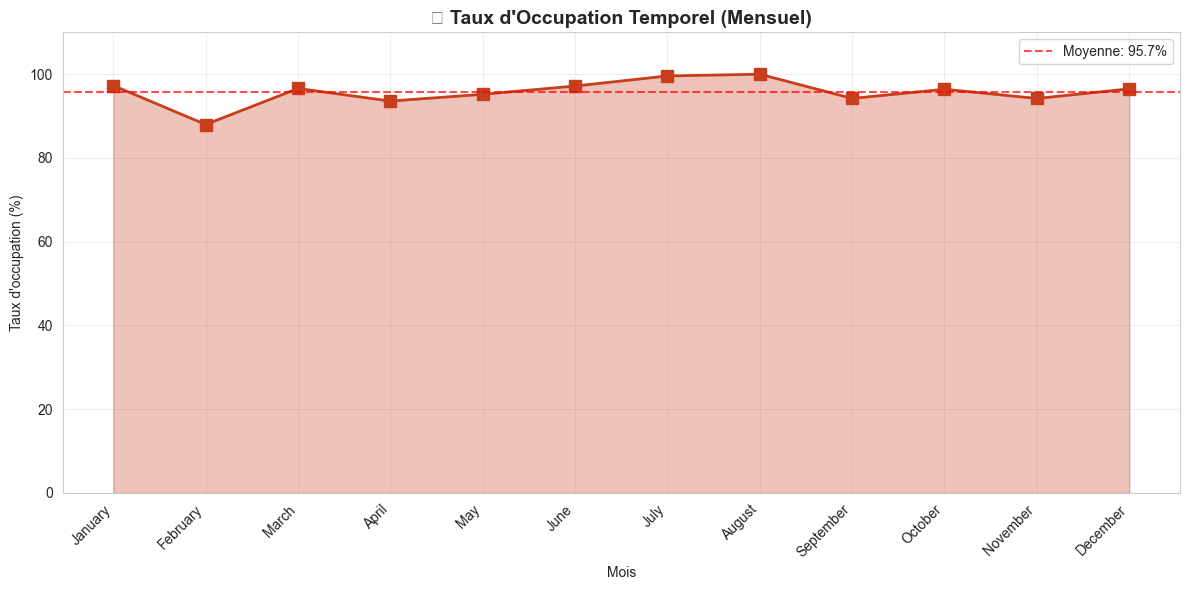

In [67]:
fig, ax = plt.subplots(figsize=(12, 6))

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

monthly_occupancy = df_bi.groupby('month_name').agg({
    'total_patients': 'sum',
    'admission_count': 'count'
}).reindex(month_order)

# Calculer le taux d'occupation (normalisé)
max_patients = monthly_occupancy['total_patients'].max()
occupancy_rate = (monthly_occupancy['total_patients'] / max_patients * 100)

ax.plot(occupancy_rate.values, marker='s', linewidth=2, markersize=8, color='#C73E1D')
ax.fill_between(range(len(occupancy_rate)), occupancy_rate.values, alpha=0.3, color='#C73E1D')
ax.set_title('📈 Taux d\'Occupation Temporel (Mensuel)', fontweight='bold', fontsize=14)
ax.set_xlabel('Mois')
ax.set_ylabel("Taux d'occupation (%)")
ax.set_xticks(range(len(month_order)))
ax.set_xticklabels(month_order, rotation=45, ha='right')
ax.set_ylim(0, 110)

# Ligne de moyenne
avg_rate = occupancy_rate.mean()
ax.axhline(y=avg_rate, color='red', linestyle='--', alpha=0.7, label=f'Moyenne: {avg_rate:.1f}%')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('kpi7_taux_occupation.png', dpi=300, bbox_inches='tight')
plt.show()

<h4 style='color:pink;'><center> KPI 8: Répartition des admissions par région </center></h4>

C:\Users\khadd\AppData\Local\Temp\ipykernel_11828\2716203011.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_region = pd.read_sql(query_region, pgconn)
C:\Users\khadd\AppData\Local\Temp\ipykernel_11828\2716203011.py:26: UserWarning: Glyph 127973 (\N{HOSPITAL}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\khadd\AppData\Local\Temp\ipykernel_11828\2716203011.py:27: UserWarning: Glyph 127973 (\N{HOSPITAL}) missing from font(s) Arial.
  plt.savefig('kpi8_admissions_par_region_barres.png', dpi=300, bbox_inches='tight')
C:\Users\khadd\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127973 (\N{HOSPITAL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


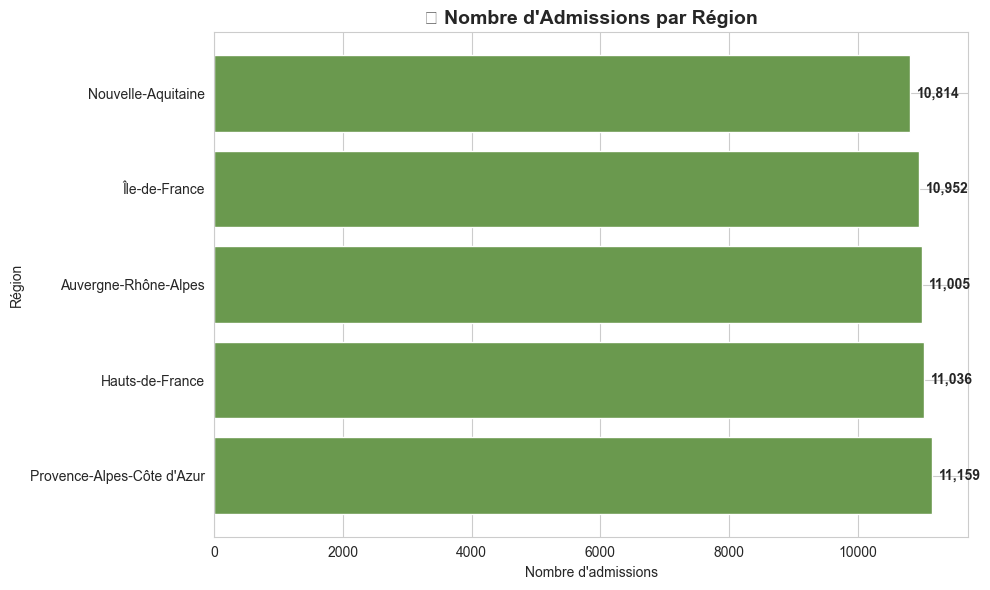

In [24]:

fig, ax = plt.subplots(figsize=(10, 6))

query_region = """
SELECT 
    dh.region,
    COUNT(*) as admissions
FROM healthcare_dwh.fact_patient_admission f
JOIN healthcare_dwh.dim_hospital dh ON f.hospital_id = dh.hospital_id
GROUP BY dh.region
ORDER BY admissions DESC
"""

df_region = pd.read_sql(query_region, pgconn)

# Barres horizontales
bars = ax.barh(df_region['region'], df_region['admissions'], color='#6A994E')
ax.set_title('🏥 Nombre d\'Admissions par Région', fontweight='bold', fontsize=14)
ax.set_xlabel('Nombre d\'admissions')
ax.set_ylabel('Région')

# Ajouter les valeurs
for bar, val in zip(bars, df_region['admissions']):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2, 
            f'{val:,.0f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('kpi8_admissions_par_region_barres.png', dpi=300, bbox_inches='tight')
plt.show()

<h3 style='color:pink;'><center>Power BI </center></h3>

In [17]:

import pandas as pd

query_export = """
SELECT 
    f.admission_id,
    f.billing_amount,
    f.length_of_stay_days,
    f.patient_count,
    p.name as patient_name,
    p.age,
    p.gender,
    p.age_group,
    h.hospital_name,
    h.hospital_type,
    h.city,
    h.region,
    d.doctor_name,
    dis.medical_condition,
    dis.category,
    ins.provider_name,
    dt.full_date,
    dt.year,
    dt.month,
    dt.month_name,
    dt.quarter,
    dt.day_name
FROM healthcare_dwh.fact_patient_admission f
JOIN healthcare_dwh.dim_patient p ON f.patient_id = p.patient_id
JOIN healthcare_dwh.dim_hospital h ON f.hospital_id = h.hospital_id
JOIN healthcare_dwh.dim_doctor d ON f.doctor_id = d.doctor_id
JOIN healthcare_dwh.dim_disease dis ON f.disease_id = dis.disease_id
JOIN healthcare_dwh.dim_insurance ins ON f.insurance_id = ins.insurance_id
JOIN healthcare_dwh.dim_date dt ON f.date_id = dt.date_id
"""

df_powerbi = pd.read_sql(query_export, pgconn)
print(f"✅ {len(df_powerbi)} lignes exportées")

df_powerbi.to_csv('healthcare_dwh_export.csv', index=False)
print("✅ Fichier sauvegardé: healthcare_dwh_export.csv")

C:\Users\khadd\AppData\Local\Temp\ipykernel_20960\490140676.py:36: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_powerbi = pd.read_sql(query_export, pgconn)


✅ 54966 lignes exportées
✅ Fichier sauvegardé: healthcare_dwh_export.csv
